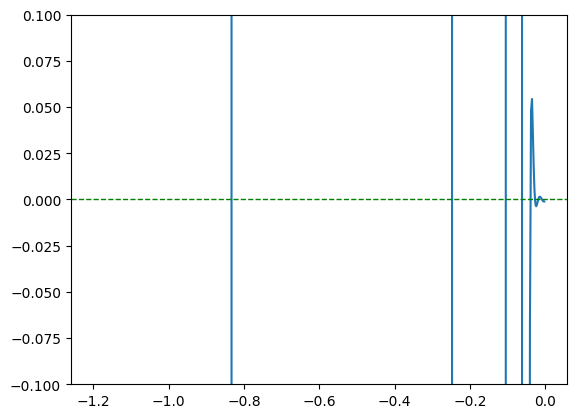

eigen values using bisect		 [-0.9999959899324795, -0.24999949503018937, -0.11111096257756999, -0.06249993772104913, -0.03999991243029425, -0.027736979872072694, -0.019192808991526783, -0.009325859589744632]


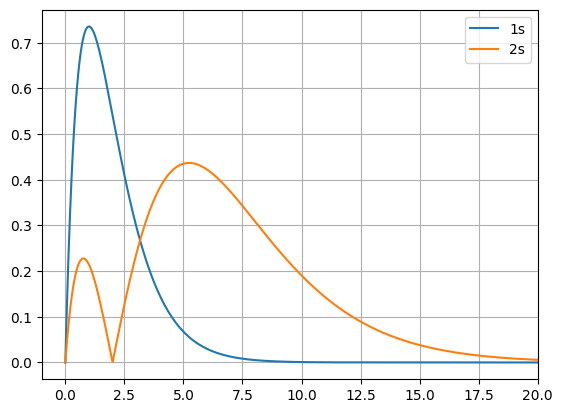

In [1]:
#TISE for Hydroden atom
# V=2/x-L(L+1)/x**2, hbar=e=m_e=a0=1 Hartree units, R(r)=U(r)/r,
# E thus found will be Hartree energy


import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint,simps
from scipy.optimize import bisect
from scipy import constants as const


# E_actual = lambda n: -2/n**2


def f(u,x,E,L):
    y,z=u
    f1,f2=z,(-2/x+L*(L+1)/x**2-E)*y
    return[f1,f2]


def shoot(E):
    sol=odeint(f,u,x,args=(E,L)) # args takes tuple as arguments
    return sol[:,0][-1]


energies=-1.2/np.arange(1,20,.2)**2     #taking near to known value
n=energies.size
xrev=np.logspace(-6,2,1000)
x=xrev[::-1]        #reversing xrev for integration stability
L=0

u=[0,0.001]  # guess value doesn't matter


eigenvalues=[]
hits=np.zeros(n)
for i,E in enumerate(energies):
    hits[i]=shoot(E)


zero_cross_indices=np.where(np.diff(np.signbit(hits)))[0]
# eigenvalues=energies[zero_cross_indices]


# eigenvalues_actual=[E_actual(n) for n in range(len(eigenvalues))]


plt.plot(energies,hits)
plt.axhline(c='g',lw=1,ls='--')
plt.ylim(-.1,.1)
plt.show()
e0=shoot(energies[0])
E0=0
En=-1
eigen_bisect=[]
for i in zero_cross_indices:
    En=bisect(shoot,energies[i],energies[i+1])
    eigen_bisect.append(En)
print('eigen values using bisect\t\t',eigen_bisect)


for i,eigen in enumerate(eigen_bisect[0:2]):
    sol=odeint(f,u,x,args=(eigen,L))
    psi=sol[:,0]
    normpsi=simps(psi**2,x)
    psi=abs(psi/np.sqrt(abs(normpsi)))
    plt.plot(x,psi,label=str(i+1)+'s')
plt.grid()
plt.xlim(-1,20)
plt.legend()

